# SRQ2 Manual Coding Analysis
**Thesis: Evaluating Multimodal LLMs on Piano Sheet Music Notation**  
Katherine (ZhaoYu) Tu — UvA 2026

## Coding guide
- **A** = right visual reading, wrong music theory, wrong final answer  
- **B** = wrong visual reading, right music theory, wrong final answer  
- **C** = reasoning too vague or unclear to determine

## Analyses in this notebook
1. Audit + patch: apply confirmed miscoding fix before any analysis  
2. Error decomposition table — per model, per sub-score, as percentages  
3. Conditional accuracy — given count correct → type correct rate; type correct → mapping correct rate  
4. Time signature: top vs bottom number accuracy per model  
5. Reasoning category distribution — % A vs B vs C per model per task  
6. Qualitative flag — cut-time symbol hallucination as a special case

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
CODING_FILE = Path('srq2_manual_coding_template_marked.csv')  # ← update path if needed
RESULTS_DIR = Path('.')                                        # ← where to save outputs

MODELS = ['claude-sonnet-4-6', 'gemini-2.5-flash', 'gpt-5.4']
MODEL_SHORT = {
    'claude-sonnet-4-6': 'Claude',
    'gemini-2.5-flash':  'Gemini',
    'gpt-5.4':           'GPT',
}
TASKS = ['key_signature', 'time_signature']

# Column aliases
COL_COUNT = 'accidental_count_correct: visual reading'
COL_TYPE  = 'accidental_type_correct: visual reading'
COL_MAP   = 'key_mapping_correct: whether the model correctly mapped from accidentals it identified to a key name - music theory application'
COL_TOP   = 'top_number_correct'
COL_BOT   = 'bottom_number_correct'
COL_SYM   = 'symbol_described_correct'
COL_CAT   = 'reasoning_category'

print('Config loaded.')

Config loaded.


## Cell 1 — Load data + apply confirmed miscoding fix

In [2]:
df = pd.read_csv(CODING_FILE)
print(f'Loaded {len(df)} rows from {CODING_FILE.name}')
print(f'Models: {df["model"].unique().tolist()}')
print(f'Tasks:  {df["question_type"].unique().tolist()}')
print()
print('Raw reasoning_category distribution:')
print(df[COL_CAT].value_counts(dropna=False))

# ── CONFIRMED MISCODING FIX ───────────────────────────────────────────────────
# gpt-5.4 | piece 31-3 | key_signature
# Sub-scores: count=correct, type=correct → visual reading was right → should be A not B
# The model correctly identified 4 flats but chose Bb minor instead of Ab major/F minor
# → right visual reading, wrong music theory application (mode selection) → A
mask_fix = (
    (df['piece_id'] == '31-3') &
    (df['model'] == 'gpt-5.4') &
    (df['question_type'] == 'key_signature')
)
old_val = df.loc[mask_fix, COL_CAT].values[0]
df.loc[mask_fix, COL_CAT] = 'A'
print(f'\nApplied fix: gpt-5.4 | 31-3 | key_signature  {old_val} → A')
print()
print('Corrected reasoning_category distribution:')
print(df[COL_CAT].value_counts(dropna=False))

Loaded 127 rows from srq2_manual_coding_template_marked.csv
Models: ['claude-sonnet-4-6', 'gemini-2.5-flash', 'gpt-5.4']
Tasks:  ['key_signature', 'time_signature']

Raw reasoning_category distribution:
reasoning_category
B    117
A      8
C      2
Name: count, dtype: int64

Applied fix: gpt-5.4 | 31-3 | key_signature  B → A

Corrected reasoning_category distribution:
reasoning_category
B    116
A      9
C      2
Name: count, dtype: int64


## Cell 2 — Helper: normalise sub-score values to bool

In [3]:
def to_bool(series):
    """Convert 'correct'/'incorrect'/NaN to True/False/NaN. Idempotent."""
    def convert(x):
        if isinstance(x, bool):              # already converted
            return x
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if s == 'correct':
            return True
        if s == 'incorrect':
            return False
        return np.nan
    return series.map(convert)


# Apply to all sub-score columns
for col in [COL_COUNT, COL_TYPE, COL_MAP, COL_TOP, COL_BOT, COL_SYM]:
    df[col] = to_bool(df[col])

# Separate by task
df_key  = df[df['question_type'] == 'key_signature'].copy()
df_time = df[df['question_type'] == 'time_signature'].copy()

print(f'key_signature rows : {len(df_key)}')
print(f'time_signature rows: {len(df_time)}')

key_signature rows : 65
time_signature rows: 62


## Cell 3 — Analysis 1: Error decomposition table

In [4]:
print('=' * 72)
print('ANALYSIS 1 — Error Decomposition (% incorrect per sub-score, per model)')
print('=' * 72)
print('(All rows are wrong-answer cases — 100% = all wrong cases for that model/task)')

decomp_records = []

# ── KEY SIGNATURE ─────────────────────────────────────────────────────────────
print('\n── Key Signature ──')
print(f'{"Model":<10} {"n":>4}  {"Count wrong":>12}  {"Type wrong":>10}  {"Mapping wrong":>14}')
print('-' * 55)
for model in MODELS:
    sub = df_key[df_key['model'] == model]
    n   = len(sub)
    if n == 0:
        continue
    count_wrong = (sub[COL_COUNT] == False).mean() * 100
    type_wrong  = (sub[COL_TYPE]  == False).mean() * 100
    map_wrong   = (sub[COL_MAP]   == False).mean() * 100
    short = MODEL_SHORT[model]
    print(f'{short:<10} {n:>4}  {count_wrong:>11.1f}%  {type_wrong:>9.1f}%  {map_wrong:>13.1f}%')
    for col, label in [(COL_COUNT, 'count_wrong'), (COL_TYPE, 'type_wrong'), (COL_MAP, 'map_wrong')]:
        val = (sub[col] == False).mean() * 100
        decomp_records.append({'task': 'key_signature', 'model': short,
                                'sub_score': label, 'pct_incorrect': round(val, 1)})

# ── TIME SIGNATURE ────────────────────────────────────────────────────────────
print('\n── Time Signature ──')
print(f'{"Model":<10} {"n":>4}  {"Top wrong":>10}  {"Bottom wrong":>12}  {"Symbol wrong":>13}')
print('-' * 55)
for model in MODELS:
    sub = df_time[df_time['model'] == model]
    n   = len(sub)
    if n == 0:
        continue
    top_wrong = (sub[COL_TOP] == False).mean() * 100
    bot_wrong = (sub[COL_BOT] == False).mean() * 100
    sym_wrong = (sub[COL_SYM] == False).mean() * 100
    short = MODEL_SHORT[model]
    print(f'{short:<10} {n:>4}  {top_wrong:>9.1f}%  {bot_wrong:>11.1f}%  {sym_wrong:>12.1f}%')
    for col, label in [(COL_TOP, 'top_wrong'), (COL_BOT, 'bot_wrong'), (COL_SYM, 'symbol_wrong')]:
        val = (sub[col] == False).mean() * 100
        decomp_records.append({'task': 'time_signature', 'model': short,
                                'sub_score': label, 'pct_incorrect': round(val, 1)})

decomp_df = pd.DataFrame(decomp_records)
decomp_df.to_csv(RESULTS_DIR / 'srq2_error_decomposition.csv', index=False)
print('\nSaved to srq2_error_decomposition.csv')

ANALYSIS 1 — Error Decomposition (% incorrect per sub-score, per model)
(All rows are wrong-answer cases — 100% = all wrong cases for that model/task)

── Key Signature ──
Model         n   Count wrong  Type wrong   Mapping wrong
-------------------------------------------------------
Claude       12         91.7%        0.0%            8.3%
Gemini       42         97.6%       31.0%            9.5%
GPT          11         36.4%       27.3%           45.5%

── Time Signature ──
Model         n   Top wrong  Bottom wrong   Symbol wrong
-------------------------------------------------------
Claude        5       40.0%        100.0%         100.0%
Gemini       47       85.1%         55.3%         100.0%
GPT          10       70.0%         80.0%         100.0%

Saved to srq2_error_decomposition.csv


## Cell 4 — Analysis 1 (visualised): Error decomposition heatmap

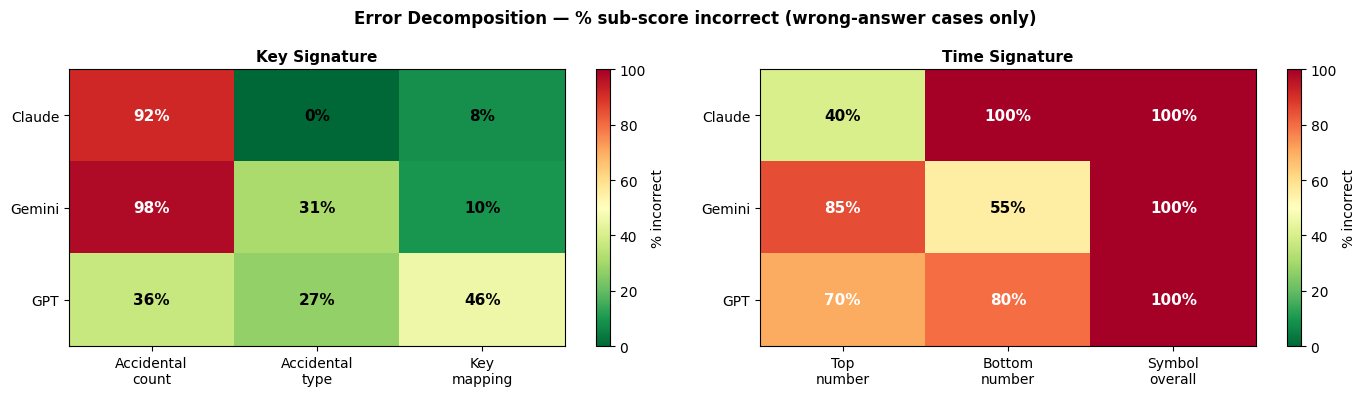

Saved to srq2_error_decomposition.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Error Decomposition — % sub-score incorrect (wrong-answer cases only)',
             fontsize=12, fontweight='bold')

task_configs = [
    ('key_signature',  ['count_wrong', 'type_wrong', 'map_wrong'],
     ['Accidental\ncount', 'Accidental\ntype', 'Key\nmapping']),
    ('time_signature', ['top_wrong', 'bot_wrong', 'symbol_wrong'],
     ['Top\nnumber', 'Bottom\nnumber', 'Symbol\noverall']),
]

for ax, (task, score_keys, score_labels) in zip(axes, task_configs):
    sub = decomp_df[decomp_df['task'] == task]
    pivot = sub.pivot(index='model', columns='sub_score', values='pct_incorrect')
    pivot = pivot.reindex(columns=score_keys)
    pivot = pivot.reindex([MODEL_SHORT[m] for m in MODELS if MODEL_SHORT[m] in pivot.index])

    im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(score_keys)))
    ax.set_xticklabels(score_labels, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    ax.set_title(task.replace('_', ' ').title(), fontsize=11, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(len(score_keys)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if val > 60 else 'black')

    plt.colorbar(im, ax=ax, label='% incorrect')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'srq2_error_decomposition.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved to srq2_error_decomposition.png')

## Cell 5 — Analysis 2: Conditional accuracy (key signature pipeline)

In [6]:
print('=' * 72)
print('ANALYSIS 2 — Conditional Accuracy (key signature only)')
print('Q1: given count correct → what % also got type correct?')
print('Q2: given type correct  → what % also got mapping correct?')
print('=' * 72)
print('(This shows whether visual accuracy at step N predicts step N+1 accuracy)')

cond_records = []

for model in MODELS:
    sub   = df_key[df_key['model'] == model]
    short = MODEL_SHORT[model]

    # Q1: count correct → type correct
    count_correct = sub[sub[COL_COUNT] == True]
    n_count_ok    = len(count_correct)
    type_given_count = count_correct[COL_TYPE].mean() * 100 if n_count_ok > 0 else np.nan

    # Q2: type correct → mapping correct
    type_correct  = sub[sub[COL_TYPE] == True]
    n_type_ok     = len(type_correct)
    map_given_type = type_correct[COL_MAP].mean() * 100 if n_type_ok > 0 else np.nan

    # Q3: unconditional mapping rate (baseline)
    map_uncond = sub[COL_MAP].mean() * 100

    print(f'\n  {short}  (n={len(sub)} wrong-answer key_sig cases)')
    print(f'    Count correct (n={n_count_ok}):  type correct given count correct = '
          f'{type_given_count:.1f}%' if not np.isnan(type_given_count) else
          f'    Count correct (n=0): no cases')
    print(f'    Type correct  (n={n_type_ok}): mapping correct given type correct = '
          f'{map_given_type:.1f}%' if not np.isnan(map_given_type) else
          f'    Type correct  (n=0): no cases')
    print(f'    Unconditional mapping correct rate = {map_uncond:.1f}%')

    cond_records.append({
        'model': short,
        'n_count_correct': n_count_ok,
        'type_given_count_correct_pct': round(type_given_count, 1) if not np.isnan(type_given_count) else None,
        'n_type_correct': n_type_ok,
        'map_given_type_correct_pct': round(map_given_type, 1) if not np.isnan(map_given_type) else None,
        'map_unconditional_pct': round(map_uncond, 1),
    })

cond_df = pd.DataFrame(cond_records)
cond_df.to_csv(RESULTS_DIR / 'srq2_conditional_accuracy.csv', index=False)
print('\nSaved to srq2_conditional_accuracy.csv')

ANALYSIS 2 — Conditional Accuracy (key signature only)
Q1: given count correct → what % also got type correct?
Q2: given type correct  → what % also got mapping correct?
(This shows whether visual accuracy at step N predicts step N+1 accuracy)

  Claude  (n=12 wrong-answer key_sig cases)
    Count correct (n=1):  type correct given count correct = 100.0%
    Type correct  (n=12): mapping correct given type correct = 91.7%
    Unconditional mapping correct rate = 91.7%

  Gemini  (n=42 wrong-answer key_sig cases)
    Count correct (n=1):  type correct given count correct = 100.0%
    Type correct  (n=29): mapping correct given type correct = 96.6%
    Unconditional mapping correct rate = 90.5%

  GPT  (n=11 wrong-answer key_sig cases)
    Count correct (n=7):  type correct given count correct = 100.0%
    Type correct  (n=8): mapping correct given type correct = 37.5%
    Unconditional mapping correct rate = 54.5%

Saved to srq2_conditional_accuracy.csv


## Cell 6 — Analysis 3: Time signature — top vs bottom number accuracy per model

ANALYSIS 3 — Time Signature: Top vs Bottom Number Accuracy
(Are models more likely to misread the top or bottom number?)

Model           n   Top wrong  Bottom wrong  Both wrong  Only top  Only bot
--------------------------------------------------------------------
Claude          5       40.0%        100.0%       40.0%      0.0%     60.0%
Gemini         47       85.1%         55.3%       40.4%     44.7%     14.9%
GPT            10       70.0%         80.0%       50.0%     20.0%     30.0%


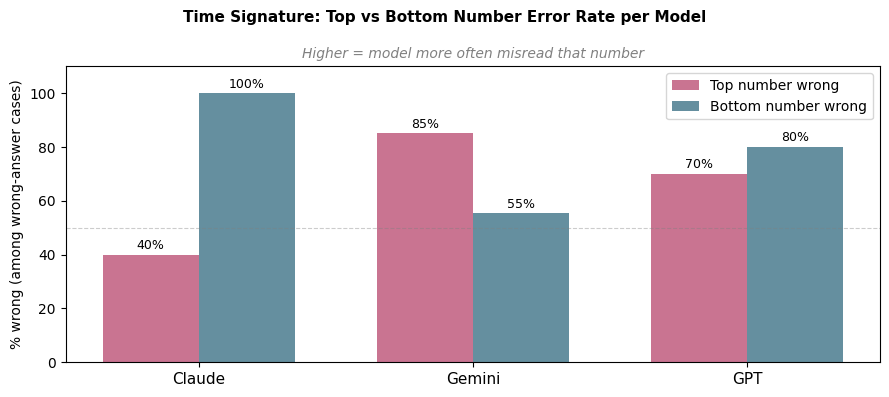


Saved to srq2_top_vs_bottom.png and .csv


In [7]:
print('=' * 72)
print('ANALYSIS 3 — Time Signature: Top vs Bottom Number Accuracy')
print('(Are models more likely to misread the top or bottom number?)')
print('=' * 72)

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Time Signature: Top vs Bottom Number Error Rate per Model',
             fontsize=11, fontweight='bold')

topbot_records = []
x        = np.arange(len(MODELS))
width    = 0.35
top_vals = []
bot_vals = []

print(f'\n{"Model":<12} {"n":>4}  {"Top wrong":>10}  {"Bottom wrong":>12}  {"Both wrong":>10}  {"Only top":>8}  {"Only bot":>8}')
print('-' * 68)

for model in MODELS:
    sub   = df_time[df_time['model'] == model]
    n     = len(sub)
    short = MODEL_SHORT[model]

    top_wrong  = (sub[COL_TOP] == False).mean() * 100
    bot_wrong  = (sub[COL_BOT] == False).mean() * 100
    both_wrong = ((sub[COL_TOP] == False) & (sub[COL_BOT] == False)).mean() * 100
    only_top   = ((sub[COL_TOP] == False) & (sub[COL_BOT] == True)).mean()  * 100
    only_bot   = ((sub[COL_TOP] == True)  & (sub[COL_BOT] == False)).mean() * 100

    print(f'{short:<12} {n:>4}  {top_wrong:>9.1f}%  {bot_wrong:>11.1f}%  {both_wrong:>9.1f}%  {only_top:>7.1f}%  {only_bot:>7.1f}%')
    top_vals.append(top_wrong)
    bot_vals.append(bot_wrong)

    topbot_records.append({
        'model': short, 'n': n,
        'top_wrong_pct': round(top_wrong, 1),
        'bot_wrong_pct': round(bot_wrong, 1),
        'both_wrong_pct': round(both_wrong, 1),
        'only_top_wrong_pct': round(only_top, 1),
        'only_bot_wrong_pct': round(only_bot, 1),
    })

short_labels = [MODEL_SHORT[m] for m in MODELS]
bars1 = ax.bar(x - width/2, top_vals, width, label='Top number wrong', color='#c05c7e', alpha=0.85)
bars2 = ax.bar(x + width/2, bot_vals, width, label='Bottom number wrong', color='#4a7c8e', alpha=0.85)

for bar, val in zip(bars1, top_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, bot_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=11)
ax.set_ylabel('% wrong (among wrong-answer cases)', fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.set_title('Higher = model more often misread that number', fontsize=10,
             style='italic', color='gray')
ax.axhline(50, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'srq2_top_vs_bottom.png', dpi=130, bbox_inches='tight')
plt.show()

pd.DataFrame(topbot_records).to_csv(RESULTS_DIR / 'srq2_top_vs_bottom.csv', index=False)
print('\nSaved to srq2_top_vs_bottom.png and .csv')

## Cell 7 — Analysis 4: Reasoning category distribution

ANALYSIS 4 — Reasoning Category Distribution (A vs B vs C)
A = right visual reading, wrong music theory
B = wrong visual reading, right music theory
C = too vague to determine

── Claude ──
  key_signature: A=1/12 (8%)  B=11/12 (92%)  C=0/12 (0%)
  time_signature: A=0/5 (0%)  B=5/5 (100%)  C=0/5 (0%)

── Gemini ──
  key_signature: A=1/42 (2%)  B=39/42 (93%)  C=2/42 (5%)
  time_signature: A=0/47 (0%)  B=47/47 (100%)  C=0/47 (0%)

── GPT ──
  key_signature: A=7/11 (64%)  B=4/11 (36%)  C=0/11 (0%)
  time_signature: A=0/10 (0%)  B=10/10 (100%)  C=0/10 (0%)


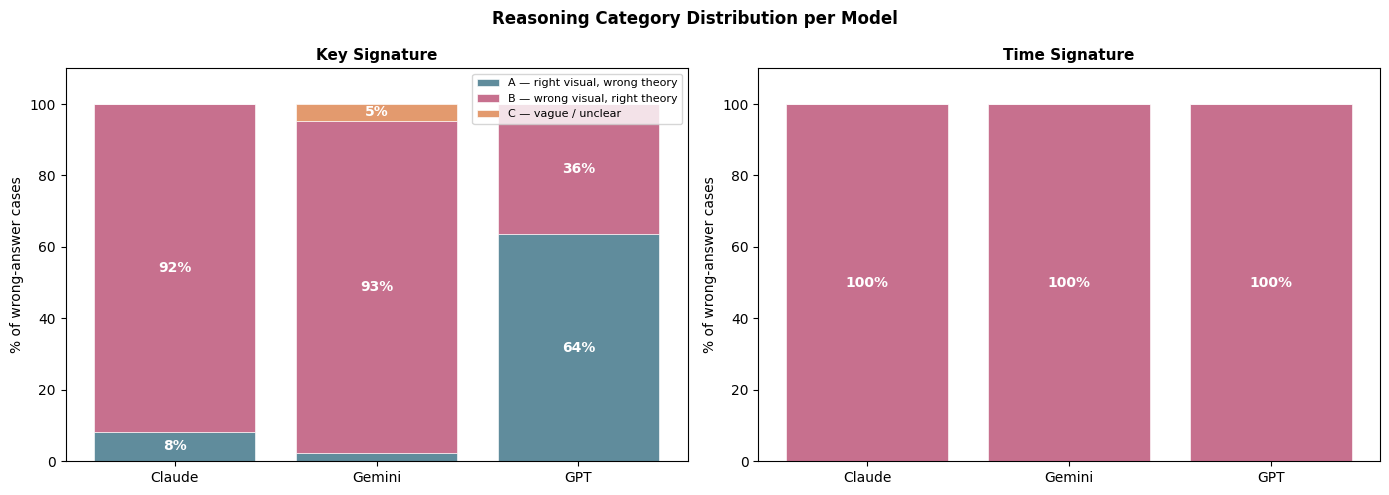

Saved to srq2_category_distribution.png and .csv


In [8]:
print('=' * 72)
print('ANALYSIS 4 — Reasoning Category Distribution (A vs B vs C)')
print('=' * 72)
print('A = right visual reading, wrong music theory')
print('B = wrong visual reading, right music theory')
print('C = too vague to determine')

cat_records = []

for model in MODELS:
    short = MODEL_SHORT[model]
    print(f'\n── {short} ──')
    for task in TASKS:
        sub = df[(df['model'] == model) & (df['question_type'] == task)]
        n   = len(sub)
        if n == 0:
            continue
        counts = sub[COL_CAT].value_counts()
        for cat in ['A', 'B', 'C']:
            cnt = counts.get(cat, 0)
            pct = cnt / n * 100
            cat_records.append({
                'model': short, 'task': task, 'category': cat,
                'count': cnt, 'pct': round(pct, 1), 'n_total': n
            })
        line = '  '.join(
            f"{cat}={counts.get(cat,0)}/{n} ({counts.get(cat,0)/n*100:.0f}%)"
            for cat in ['A','B','C']
        )
        print(f'  {task}: {line}')

cat_df = pd.DataFrame(cat_records)

# ── VISUALISE ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reasoning Category Distribution per Model',
             fontsize=12, fontweight='bold')

cat_colours = {'A': '#4a7c8e', 'B': '#c05c7e', 'C': '#e08c5a'}
cat_labels  = {'A': 'A — right visual, wrong theory',
               'B': 'B — wrong visual, right theory',
               'C': 'C — vague / unclear'}

for ax, task in zip(axes, TASKS):
    sub = cat_df[cat_df['task'] == task]
    pivot = sub.pivot(index='model', columns='category', values='pct').fillna(0)
    pivot = pivot.reindex([MODEL_SHORT[m] for m in MODELS if MODEL_SHORT[m] in pivot.index])
    pivot = pivot.reindex(columns=['A', 'B', 'C'], fill_value=0)

    bottom = np.zeros(len(pivot))
    for cat in ['A', 'B', 'C']:
        vals = pivot[cat].values
        bars = ax.bar(pivot.index, vals, bottom=bottom,
                      color=cat_colours[cat], label=cat_labels[cat],
                      alpha=0.88, edgecolor='white', linewidth=0.5)
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 4:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bot + val/2,
                        f'{val:.0f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
        bottom += vals

    ax.set_ylim(0, 110)
    ax.set_ylabel('% of wrong-answer cases', fontsize=10)
    ax.set_title(task.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    if task == TASKS[0]:
        ax.legend(loc='upper right', fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'srq2_category_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

cat_df.to_csv(RESULTS_DIR / 'srq2_category_distribution.csv', index=False)
print('Saved to srq2_category_distribution.png and .csv')

## Cell 8 — Analysis 5: Qualitative flag — cut-time symbol hallucination

In [9]:
print('=' * 72)
print('ANALYSIS 5 — Cut-Time Symbol Hallucination (Claude special case)')
print('=' * 72)
print('These are cases where a model described seeing a C or cut-C symbol')
print('(common time / alla breve) rather than the actual numeric time signature.')
print('This is a qualitative failure mode distinct from misreading numbers.')

CUT_PATTERN = r'cut|common time|alla breve|\u{1D135}|C symbol|"C"|cut common|cut-c|cut C'

cut_rows = df[
    (df['question_type'] == 'time_signature') &
    (df['reasoning'].str.contains(
        'cut|common time|alla breve|C symbol|cut common|"C"',
        case=False, na=False, regex=True
    ))
].copy()

print(f'\nCases found: {len(cut_rows)}')
print()

for _, row in cut_rows.iterrows():
    model_s   = MODEL_SHORT.get(row['model'], row['model'])
    gt        = row['ground_truth']
    ans       = row['parsed_answer']
    cat       = row[COL_CAT]
    reasoning = str(row['reasoning'])

    # Extract the sentence containing the cut-time mention
    sentences = reasoning.replace('\n', ' ').split('.')
    flagged   = [s.strip() for s in sentences
                 if any(kw in s.lower() for kw in
                        ['cut', 'common time', 'alla breve', 'c symbol', '"c"'])]

    print(f'  {row["piece_id"]} | {model_s} | GT={gt} | predicted={ans} | category={cat}')
    for s in flagged:
        print(f'    "{s[:200]}"')
    print()

# ── SUMMARY NOTE ──────────────────────────────────────────────────────────────
n_models_affected = cut_rows['model'].nunique()
models_affected   = [MODEL_SHORT.get(m, m) for m in cut_rows['model'].unique()]

print('-' * 72)
print(f'Summary:')
print(f'  Total cut-time hallucination cases : {len(cut_rows)}')
print(f'  Models affected                    : {models_affected}')
print(f'  All from Claude                    : {set(cut_rows["model"].unique()) == {"claude-sonnet-4-6"}}')
print()
print('Interpretation:')
print('  Claude appears to confuse numeric time signatures with symbolic notation')
print('  (C = common time, cut-C = alla breve = 2/2). This is a qualitative visual')
print('  parsing failure specific to ambiguous score rendering, not a music theory error.')
print()
print('Thesis note: flag these as a sub-category of Category B for Claude.')
print('They are wrong visual reading, but the error mechanism is symbol confusion')
print('rather than miscounting — worth a 1-sentence mention in the qualitative section.')

# Save the flagged cases
cut_rows[['piece_id', 'model', 'ground_truth', 'parsed_answer', COL_CAT]].to_csv(
    RESULTS_DIR / 'srq2_cut_time_hallucinations.csv', index=False
)
print('\nSaved to srq2_cut_time_hallucinations.csv')

ANALYSIS 5 — Cut-Time Symbol Hallucination (Claude special case)
These are cases where a model described seeing a C or cut-C symbol
(common time / alla breve) rather than the actual numeric time signature.
This is a qualitative failure mode distinct from misreading numbers.

Cases found: 4

  13-1 | Claude | GT=2/2 | predicted=4/4 | category=B
    "It appears as a "C" symbol, which is the common time symbol, equivalent to 4/4"
    "However, looking more carefully at the score, I can see what appears to be a cut common time or a "C" with a vertical line — but examining the notation more carefully, the symbol at the start of the A"
    "(2) What the numbers represent:  The common time symbol "C" represents 4/4 time: - The top number 4 means there are 4 beats per measure - The bottom number 4 means the quarter note receives one beat  "

  13-4 | Claude | GT=2/4 | predicted=2/2 | category=B
    "The numbers appear to be 2 on top and 2 on the bottom, giving a "cut time" or 2/2 appearance"
 

## Cell 9 — Summary table: all analyses in one printout

In [10]:
print('=' * 72)
print('SRQ2 CODING ANALYSIS — EXECUTIVE SUMMARY')
print('=' * 72)

print(f'\nTotal wrong-answer cases analysed: {len(df)}')
print(f'  key_signature  : {len(df_key)}')
print(f'  time_signature : {len(df_time)}')

print('\nReasoning category totals (after miscoding fix):')
for cat, desc in [('A', 'right visual, wrong theory'),
                  ('B', 'wrong visual, right theory'),
                  ('C', 'vague/unclear')]:
    n   = (df[COL_CAT] == cat).sum()
    pct = n / len(df) * 100
    print(f'  {cat}: {n:>3} / {len(df)}  ({pct:.1f}%)  — {desc}')

print('\nKey finding: which model shows most Category A (theory error, not visual)?')
for model in MODELS:
    sub   = df[df['model'] == model]
    n_a   = (sub[COL_CAT] == 'A').sum()
    total = len(sub)
    print(f'  {MODEL_SHORT[model]:<8}: {n_a}/{total} ({n_a/total*100:.0f}%) Category A')

print('\nFiles saved:')
for fname in [
    'srq2_error_decomposition.csv',
    'srq2_error_decomposition.png',
    'srq2_conditional_accuracy.csv',
    'srq2_top_vs_bottom.csv',
    'srq2_top_vs_bottom.png',
    'srq2_category_distribution.csv',
    'srq2_category_distribution.png',
    'srq2_cut_time_hallucinations.csv',
]:
    print(f'  {fname}')

SRQ2 CODING ANALYSIS — EXECUTIVE SUMMARY

Total wrong-answer cases analysed: 127
  key_signature  : 65
  time_signature : 62

Reasoning category totals (after miscoding fix):
  A:   9 / 127  (7.1%)  — right visual, wrong theory
  B: 116 / 127  (91.3%)  — wrong visual, right theory
  C:   2 / 127  (1.6%)  — vague/unclear

Key finding: which model shows most Category A (theory error, not visual)?
  Claude  : 1/17 (6%) Category A
  Gemini  : 1/89 (1%) Category A
  GPT     : 7/21 (33%) Category A

Files saved:
  srq2_error_decomposition.csv
  srq2_error_decomposition.png
  srq2_conditional_accuracy.csv
  srq2_top_vs_bottom.csv
  srq2_top_vs_bottom.png
  srq2_category_distribution.csv
  srq2_category_distribution.png
  srq2_cut_time_hallucinations.csv
